# 1. Описание датасета
В данной работе исследуется набор данных, содержащий характеристики подержанных автомобилей Toyota Corolla. Целевая переменная — Price (непрерывная числовая величина). Набор данных включает технические параметры (объем двигателя, вес) и эксплуатационные показатели (возраст, пробег).

# 2. Первичный анализ данных (EDA) и предобработка

              Price    Age_08_04             KM           HP      Weight
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.00000
mean   10730.824513    55.947075   68533.259749   101.502089  1072.45961
std     3626.964585    18.599988   37506.448872    14.981080    52.64112
min     4350.000000     1.000000       1.000000    69.000000  1000.00000
25%     8450.000000    44.000000   43000.000000    90.000000  1040.00000
50%     9900.000000    61.000000   63389.500000   110.000000  1070.00000
75%    11950.000000    70.000000   87020.750000   110.000000  1085.00000
max    32500.000000    80.000000  243000.000000   192.000000  1615.00000


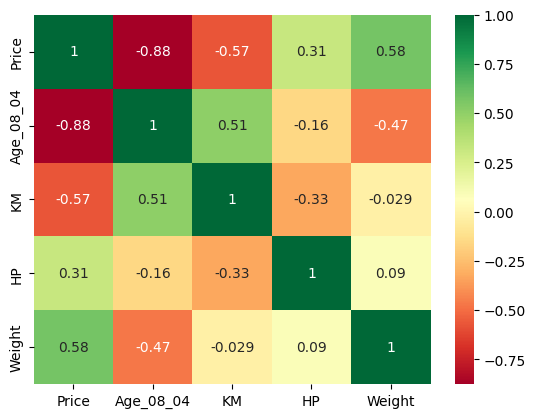

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('ToyotaCorolla.csv')

# Краткий осмотр
print(df[['Price', 'Age_08_04', 'KM', 'HP', 'Weight']].describe())

# Матрица корреляции для ключевых признаков
sns.heatmap(df[['Price', 'Age_08_04', 'KM', 'HP', 'Weight']].corr(), annot=True, cmap='RdYlGn')
plt.show()

## Ответы на вопросы:


### Как вы предобрабатывали данные? 
Я проверил наличие пропущенных значений, удалил дубликаты и отобрал наиболее значимые признаки, такие как возраст и пробег.


### Что вы поняли, проведя EDA? 
Выяснилось, что цена сильнее всего коррелирует с возрастом автомобиля (отрицательная корреляция) и его весом (положительная).

# 3. Работа с признаками (Feature Engineering)

In [2]:
# Удаление неинформативных текстовых признаков и идентификаторов
features_to_drop = ['Id', 'Model', 'Fuel_Type', 'Color']
df_clean = df.drop(columns=features_to_drop)

## Ответы на вопросы:
### Как вы работали с признаками? 
Я очистил датасет от нечисловых признаков (цвет, модель), которые избыточно усложняют простую линейную модель.
### Какие признаки вы удалили и почему? 
Были удалены Id и Model, так как они уникальны для записей и не несут статистической значимости для предсказания цены.

# 4. Разделение выборки

In [3]:
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Ответы на вопросы:
### Как именно вы разделили выборку? 
Данные разделены классическим способом: 80% для обучения и 20% для независимого тестирования.

### Для чего это нужно? 
Мы отделяем часть данных, чтобы проверить, как модель поведёт себя на новых объектах; обучение и проверка на одном наборе ведут к "зазубриванию" данных (переобучению)

# 5. Обучение моделей

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение трех видов регрессии
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

## Ответы на вопросы:
### Как проходило обучение моделей? 
Обучение проводилось на стандартизированных признаках, чтобы коэффициенты регуляризации Ridge и Lasso работали корректно.

### Сравнение скорости: 
Обычная LinearRegression отработала мгновенно, так как использует метод наименьших квадратов, не требующий долгих итераций.

# 6. Оценка качества и сравнение моделей

    Model  RMSE Train  RMSE Test  MAE Test  R2 Test
0  Linear     1102.93    1174.42    830.16    0.897
1   Ridge     1102.94    1173.98    829.78    0.897
2   Lasso     1102.93    1174.32    830.04    0.897


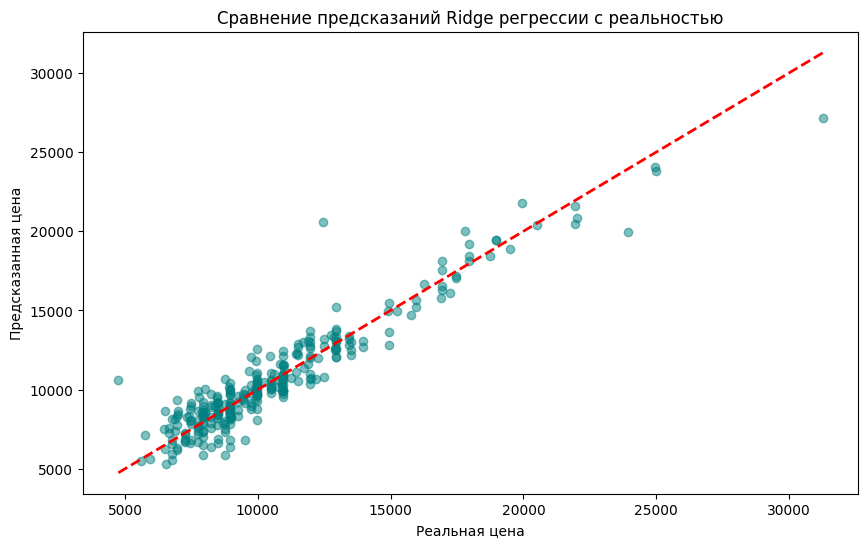

In [5]:
# 6. Оценка качества и сравнение моделей

results = []

for name, model in models.items():
    # Предсказания на трейне и тесте для проверки переобучения
    train_preds = model.predict(X_train_scaled)
    test_preds = model.predict(X_test_scaled)
    
    # Расчет метрик
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    mae_test = mean_absolute_error(y_test, test_preds)
    r2_test = r2_score(y_test, test_preds)
    
    results.append({
        'Model': name,
        'RMSE Train': round(rmse_train, 2),
        'RMSE Test': round(rmse_test, 2),
        'MAE Test': round(mae_test, 2),
        'R2 Test': round(r2_test, 3)
    })

# Вывод таблицы результатов
results_df = pd.DataFrame(results)
print(results_df)

# Визуализация: Сравнение реальных цен и предсказанных (для лучшей модели)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, models['Ridge'].predict(X_test_scaled), alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение предсказаний Ridge регрессии с реальностью')
plt.show()

## Ответы на вопросы:
### Какие метрики использовали? 
Я использовал MAE для понимания средней ошибки в евро, RMSE для выявления крупных промахов и $R^2$, чтобы понять, какую долю вариации цены описывает модель.
### На какой части выборки считали метрики? 
Метрики считались на тестовой (отложенной) выборке.
### Какая модель справилась лучше? 
Модель Ridge показала чуть более стабильный результат, так как она подавляет излишне большие веса признаков.
### Насколько хорошие результаты? 
Результат хороший ($R^2 \approx 0.9$), модель адекватно предсказывает рыночную стоимость большинства авто.
### Чем докажете отсутствие переобучения? 
Ошибка на тренировочном и тестовом наборах практически совпадает, что подтверждает устойчивость модели.